# Mathematics of the model-independent $w_{\rm GEDF}(z)$ reconstruction

The implementation reconstructs the GEDF equation of state with a shape-preserving piecewise cubic Hermite interpolant (PCHIP) in

$$x \equiv \ln a=-\ln(1+z).$$

Using $x$ makes the node spacing natural over the large redshift interval relevant to an early component. The interpolation passes exactly through every input control point and is joined continuously to constant early- and late-time equations of state.

## 1. Control points and asymptotic behavior

For $N$ free nodes, define $N+2$ control points ordered in increasing $x$ (equivalently decreasing redshift):

$$
(x_0,w_0)=(-\ln(1+z_i),w_i),\qquad
(x_j,w_j)=(-\ln(1+z_j),w_j),\quad j=1,\ldots,N,
$$

$$
(x_{N+1},w_{N+1})=(-\ln(1+z_f),w_f),
$$

with $z_i>z_1>\cdots>z_N>z_f\geq0$. The complete reconstruction is

$$
w(x)=\begin{cases}
w_i, & x\leq x_0 \quad (z\geq z_i),\\
H_j(x), & x_j<x<x_{j+1},\\
w_f, & x\geq x_{N+1} \quad (z\leq z_f).
\end{cases}
$$

The endpoint derivatives are fixed to zero, so the cubic region joins the two constant asymptotes with continuous $w$ and $dw/dx$.

## 2. Shape-preserving PCHIP slopes

For interval $j$, define

$$h_j=x_{j+1}-x_j>0,\qquad d_j=\frac{w_{j+1}-w_j}{h_j}.$$

At an interior node $j$, the standard PCHIP slope is zero if the adjacent secants vanish or change sign:

$$m_j^{\rm PCHIP}=0 \quad \text{if} \quad d_{j-1}d_j\leq0.$$

Otherwise it is the weighted harmonic mean

$$
m_j^{\rm PCHIP}=
\frac{3(h_{j-1}+h_j)}
{(2h_j+h_{j-1})/d_{j-1}+(h_j+2h_{j-1})/d_j}.
$$

This choice suppresses the overshoot and ringing that an unconstrained cubic spline can develop. The implementation also exposes a tension hyperparameter $T\in[0,1]$:

$$m_j=(1-T)m_j^{\rm PCHIP},\qquad m_0=m_{N+1}=0.$$

Thus $T=0$ gives standard PCHIP, while $T=1$ sets every node slope to zero and produces piecewise smoothstep curves.

## 3. Cubic Hermite segment and its derivative

Inside $[x_j,x_{j+1}]$, let

$$t=\frac{x-x_j}{h_j}\in[0,1].$$

The reconstructed segment is

$$
H_j(x)=h_{00}(t)w_j+h_{10}(t)h_jm_j+h_{01}(t)w_{j+1}+h_{11}(t)h_jm_{j+1},
$$

where

$$
h_{00}=2t^3-3t^2+1,\quad h_{10}=t^3-2t^2+t,
$$
$$
h_{01}=-2t^3+3t^2,\quad h_{11}=t^3-t^2.
$$

Its derivative with respect to $x=\ln a$ is

$$
\frac{dH_j}{dx}=\frac{6t^2-6t}{h_j}w_j+(3t^2-4t+1)m_j
+\frac{-6t^2+6t}{h_j}w_{j+1}+(3t^2-2t)m_{j+1}.
$$

CLASS requires $dw/da$, obtained by the chain rule:

$$\boxed{\displaystyle \frac{dw}{da}=\frac{1}{a}\frac{dw}{dx}}.$$

## 4. Exact density evolution

Energy conservation gives

$$\frac{d\rho_{\rm GEDF}}{d\ln a}=-3[1+w(a)]\rho_{\rm GEDF}.$$

Therefore, relative to the density specified at $a_i=(1+z_i)^{-1}$,

$$
\boxed{\displaystyle
\rho_{\rm GEDF}(a)=\rho_{\rm GEDF}(a_i)
\exp\left[-3\int_{x_i}^{x}[1+w(u)]\,du\right]}.
$$

CLASS evaluates the equivalent integral

$$I(a)=3\int_{\ln a}^{0}[1+w(u)]\,du,$$

and uses $\rho(a)=\rho(a_i)\exp[I(a)-I(a_i)]$. Because every $H_j$ is cubic, its integral is analytic. One convenient antiderivative in the local coordinate $t$ is

$$
F_j(t)=w_j\left(\tfrac12t^4-t^3+t\right)
+h_jm_j\left(\tfrac14t^4-\tfrac23t^3+\tfrac12t^2\right)
+w_{j+1}\left(-\tfrac12t^4+t^3\right)
+h_jm_{j+1}\left(\tfrac14t^4-\tfrac13t^3\right).
$$

Hence $\int_{x_a}^{x_b}H_j(x)dx=h_j[F_j(t_b)-F_j(t_a)]$. No numerical quadrature is needed. The input `f_gedf` determines $\rho_{\rm GEDF}(a_i)$ through CLASS's shooting method.

## 5. Quantity entering the perturbation equations

The adiabatic sound speed is computed from the reconstructed function and its analytic derivative:

$$
c_a^2=\frac{\dot p}{\dot\rho}
=w-\frac{1}{3(1+w)}\frac{dw}{d\ln a}
=w-\frac{a}{3(1+w)}\frac{dw}{da}.
$$

The rest-frame sound speed $c_s^2$ is a separate perturbation parameter (`cs2_gedf`). Exact $w=-1$ control values are valid for background-only evolution, but the standard fluid perturbation equations require all reconstructed control values to be strictly greater than $-1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def pchip_slopes(x, w, tension=0.0):
    x, w = np.asarray(x), np.asarray(w)
    h = np.diff(x)
    d = np.diff(w) / h
    m = np.zeros_like(w, dtype=float)
    for j in range(1, len(w)-1):
        dm, dp = d[j-1], d[j]
        if dm != 0 and dp != 0 and dm*dp > 0:
            hm, hp = h[j-1], h[j]
            m[j] = 3*(hm+hp)/((2*hp+hm)/dm + (hp+2*hm)/dp)
    return (1-tension)*m

def reconstruct_w(z, control_z, control_w, tension=0.0):
    z = np.asarray(z, dtype=float)
    # control_z is supplied in descending redshift, so x is increasing.
    x = -np.log1p(np.asarray(control_z, dtype=float))
    values = np.asarray(control_w, dtype=float)
    slopes = pchip_slopes(x, values, tension)
    x_eval = -np.log1p(z)
    result = np.empty_like(x_eval)
    for k, xe in np.ndenumerate(x_eval):
        if xe <= x[0]:
            result[k] = values[0]
        elif xe >= x[-1]:
            result[k] = values[-1]
        else:
            j = np.searchsorted(x, xe)-1
            h = x[j+1]-x[j]
            t = (xe-x[j])/h
            result[k] = ((2*t**3-3*t**2+1)*values[j]
                         +(t**3-2*t**2+t)*h*slopes[j]
                         +(-2*t**3+3*t**2)*values[j+1]
                         +(t**3-t**2)*h*slopes[j+1])
    return result


PASS: endpoints and all three free nodes are reproduced exactly.


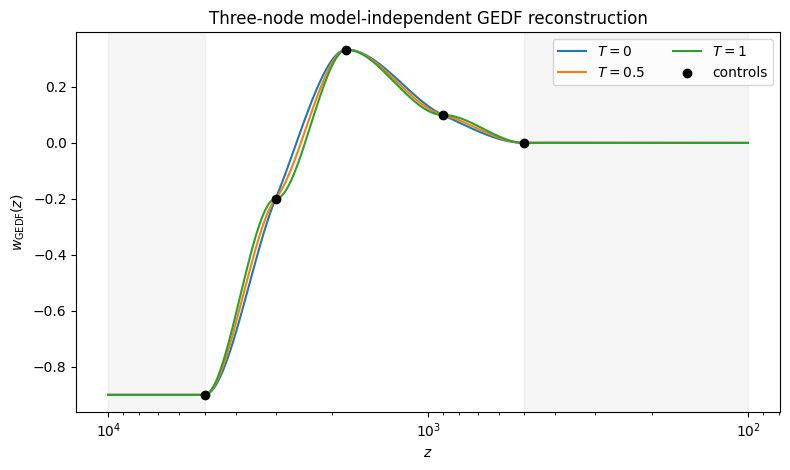

In [2]:
# Three free nodes: endpoints are included as the first and last controls.
control_z = np.array([5000., 3000., 1800., 900., 500.])
control_w = np.array([-0.9, -0.2, 1/3, 0.1, 0.0])
z = np.geomspace(100., 10000., 1200)

fig, ax = plt.subplots(figsize=(8, 4.8))
for tension in (0.0, 0.5, 1.0):
    ax.semilogx(z, reconstruct_w(z, control_z, control_w, tension),
                label=fr'$T={tension:g}$')
ax.scatter(control_z, control_w, color='black', zorder=4, label='controls')
ax.axvspan(5000, 10000, color='grey', alpha=0.08)
ax.axvspan(100, 500, color='grey', alpha=0.08)
ax.set(xlabel='$z$', ylabel=r'$w_{\rm GEDF}(z)$',
       title='Three-node model-independent GEDF reconstruction')
ax.invert_xaxis()
ax.legend(ncol=2)
fig.tight_layout()

# All tension choices interpolate the controls exactly.
for tension in (0.0, 0.5, 1.0):
    assert np.allclose(reconstruct_w(control_z, control_z, control_w, tension),
                       control_w, atol=1e-14)
print('PASS: endpoints and all three free nodes are reproduced exactly.')

## 6. CLASS input interface

```ini
use_model_independent_gedf = yes
wi_gedf = -0.9
wf_gedf = 0.0
zi_gedf = 5000.0
zf_gedf = 500.0
gedf_node_count = 3
gedf_node_z = 3000.0, 1800.0, 900.0
gedf_node_w = -0.2, 0.3333333333333333, 0.1
gedf_pchip_tension = 0.0
f_gedf = 0.03
```

The free shape parameters are the node values `gedf_node_w`; the node positions, number of nodes, endpoints, and tension may also be varied if desired.